QUESTION 1: Uniform: you dont know the ditribution and have to figure out the distribution

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import ipywidgets as widgets

In [2]:
@widgets.interact(
    K=widgets.IntSlider(value=5, min=2, max=100, step=1, description="K"),
    n=widgets.IntSlider(value=5000, min=500, max=10000, step=500, description="n")
)
def ecdf_grid_demo(K, n):
    grid = np.linspace(1 / K, 1.0, K)

    draws = np.random.choice(grid, size=n, replace=True)
    sorted_draws = np.sort(draws)
    ecdf_y = np.arange(1, n + 1) / n
    
    plt.figure(figsize=(8, 4))
    
    plt.step(sorted_draws, ecdf_y, where='post', label=f'ECDF (K={K}, n={n})', color='tab:blue', lw=2)
    
    x_theoretical = np.linspace(0, 1, 300)
    y_theoretical = stats.uniform.cdf(x_theoretical, loc=0, scale=1)
    plt.plot(x_theoretical, y_theoretical, 'r--', label='Uniform(0,1) Continuous CDF', lw=2)
    
    plt.xlabel('x')
    plt.ylabel('F(x)')
    plt.xlim(-0.05, 1.05)
    plt.ylim(-0.05, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

interactive(children=(IntSlider(value=5, description='K', min=2), IntSlider(value=5000, description='n', max=1…

<function matplotlib.pyplot.show(close=None, block=None)>

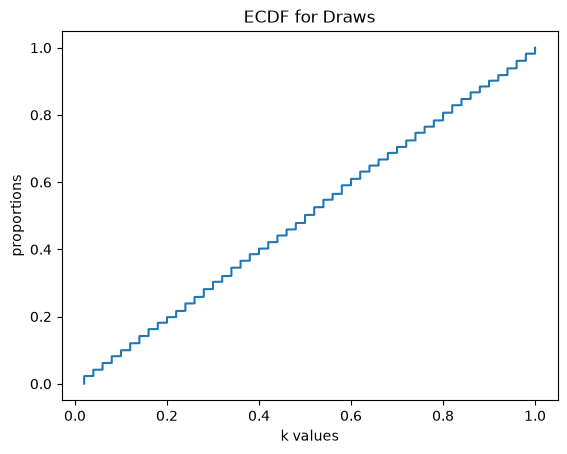

In [6]:
b= 5000
k=50
lst = []
rng = np.random.default_rng()


values = np.arange(1,(k+1))/k
for i in range (b):
    z = rng.choice(values)
    lst.append(z)


sortedlst = np.sort(lst)

x = sortedlst
y = np.arange(1, b + 1) / b

import matplotlib.pyplot as plt

plt.plot(x,y)
plt.xlabel("k values")
plt.ylabel('proportions')
plt.title('ECDF for Draws')

plt.show

Question 2: We often study sample averages: It's one of the first statistics you calculate for any dataset. What is the
distribution of the sample mean?

ANSWER: This is a uniform/normal distribution. As n increases, the distribution of the standardized sample mean approaches a standard normal distribution. In other words, he sample mean follows an approximately normal distribution.

In [3]:
#1
n = 32

a = -np.sqrt(3)
b = np.sqrt(3)

dist = stats.uniform(loc=a, scale=b-a)

data = dist.rvs(size=n)

mean = np.mean(data)

mean * np.sqrt(n)

np.float64(1.5551493184141465)

In [4]:
#2
b = 5000

means = []

for i in range(b):
    data = dist.rvs(size=n)
    mean = np.mean(data)
    means.append(mean * np.sqrt(n))

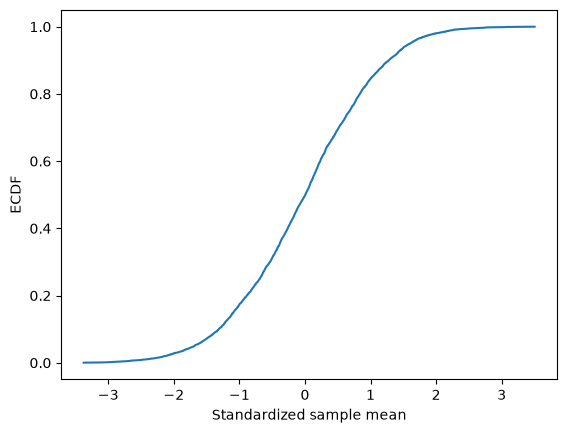

In [5]:
#3
x = np.sort(means)
y = np.arange(1, len(means) + 1) / len(means)

plt.plot(x, y)
plt.xlabel("Standardized sample mean")
plt.ylabel("ECDF")
plt.show()

QUESTION 3: In reliability engineering, we are often concerned with the proportions of failures that occur. For example,
the Challenger space shuttle exploded on January 28, 1986, when the primary and secondary o-rings failed.
Floods often occur because too many levees or pumps are compromised. In this simulation, we have 40 units
that each fail with probability , and we want to study the distribution of the survivors.